## Business Case

A financial services company runs direct mail campaigns to acquire new commercial customers. Each mail piece costs money to send, but only a small fraction of prospects ever respond — meaning most of the marketing budget is spent on people who were never going to convert. Without a way to prioritize, spend is flat across the whole list regardless of who's actually likely to respond.

## Problems to Solve

1. **Who to target** — which prospects have the highest likelihood of responding to a mail offer?
2. **How deep to mail** — at what point does mailing further down a ranked list stop being worth the cost?
3. **What's the financial impact** — how much can be saved (or earned) by mailing a prioritized list instead of mailing everyone equally?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Phase 1:** Uploading the Dataset

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### **Phase 2 :** Exploratory Data Analysis

In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### **For Categorical Columns**

In [7]:
df.describe(include='object') 

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


#### **The "unknown" values check :**
- Counted how many rows had "unknown" instead of a real value in each column, since this dataset uses that as its missing-data marker instead of blanks.

In [8]:
for col in df.columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknown values")

job: 330 unknown values
marital: 80 unknown values
education: 1731 unknown values
default: 8597 unknown values
housing: 990 unknown values
loan: 990 unknown values


#### **target balance :** 
- Checked what % of prospects actually said yes vs. no, to confirm the class imbalance (11.3% yes) that shapes every metric choice later

In [9]:
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True))

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


#### **leakage check :** 
- Compared average call duration between responders and non-responders to test whether duration was leaking the answer.

In [10]:
df.groupby('y')['duration'].mean()

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64

#### **The actual leakage fix :**
- Dropped the duration column entirely, since it only exists after the outcome is already known and wouldn't be available in a real targeting scenario.

In [11]:
df = df.drop(columns=['duration'])

In [12]:
df.shape

(41188, 20)

### **Phase 3** — Feature Engineering

In [13]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Numeric columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [14]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

In [15]:
df[['pdays', 'was_contacted_before']].head(10)

,pdays,was_contacted_before
0,999,0
1,999,0
2,999,0
3,999,0
4,999,0
5,999,0
6,999,0
7,999,0
8,999,0
9,999,0


#### **Converted target to binary :** 
- Changed the y column from "yes"/"no" text to 1/0, since models need a numeric target to predict.

In [16]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [17]:
df['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

#### **One Hot Encoding :** Encoding Categorical Columns
- Converted text categories (like job, marital status, education) into 0/1 columns the model can actually use, since models can't work with raw text. Removed `y` from this step first since the target is handled separately.

In [18]:
categorical_cols.remove('y')
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [19]:
df.shape
df.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False


In [20]:
df.shape

(41188, 54)

#### **Split into features (X) and target (y) :** 
- Separated the columns used to predict (X) from the column being predicted (y), since that's the format scikit-learn expects.

In [21]:
X = df.drop(columns=['y'])
y = df['y']

In [22]:
print(X.shape)
print(y.shape)

(41188, 53)
(41188,)


### **Train/test split :**  
- We split the data 80/20 for training and testing, making sure both parts kept the same **11%** "yes" rate as the full dataset — so the test set wasn't accidentally missing most of the rare responders just by chance.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(32950, 53) (8238, 53)
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


### **Phase 4 :** Model Building

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **Why Logistic regression ?**
- Its deliberately the simplest option, not the most complex. explainable to a non-technical stakeholder, and it performed well enough that reaching for a more complex model wasn't clearly justified.

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)
print(model)

LogisticRegression(class_weight='balanced', max_iter=1000)


## Model Evaluation

- Used precision and recall, not accuracy — accuracy is misleading here since ~89% of prospects say no anyway. For the "yes" class: precision = 0.37, recall = 0.65 — flagged prospects respond at 3x the baseline rate while catching two-thirds of all real responders.

In [27]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6281 1029]
 [ 329  599]]
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238



### **Decile Analysis**

In [28]:
import pandas as pd

# Get predicted probabilities instead of just yes/no
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Build a small results table
results = pd.DataFrame({'actual': y_test, 'predicted_prob': y_probs})

# Rank into 10 equal groups (deciles) by predicted probability
results['decile'] = pd.qcut(results['predicted_prob'], 
                            10, labels=False,
                            duplicates='drop')

# For each decile, calculate the actual response rate
decile_summary = ( results.groupby('decile')['actual']
                        .agg(['mean', 'count'])
                        .sort_index(ascending=False)
                 )

decile_summary.columns = ['response_rate', 'count']
print(decile_summary)

        response_rate  count
decile                      
9            0.509709    824
8            0.218447    824
7            0.093447    824
6            0.051033    823
5            0.053398    824
4            0.054612    824
3            0.037667    823
2            0.038835    824
1            0.036408    824
0            0.032767    824


In [29]:
total_responders = results['actual'].sum()

decile_summary['responders_captured'] = (decile_summary['response_rate'] * decile_summary['count']).round().astype(int)
decile_summary['cumulative_responders'] = decile_summary['responders_captured'].cumsum()
decile_summary['cumulative_pct_of_all_responders'] = (decile_summary['cumulative_responders'] / total_responders * 100).round(1)

print(decile_summary)

        response_rate  count  responders_captured  cumulative_responders  \
decile                                                                     
9            0.509709    824                  420                    420   
8            0.218447    824                  180                    600   
7            0.093447    824                   77                    677   
6            0.051033    823                   42                    719   
5            0.053398    824                   44                    763   
4            0.054612    824                   45                    808   
3            0.037667    823                   31                    839   
2            0.038835    824                   32                    871   
1            0.036408    824                   30                    901   
0            0.032767    824                   27                    928   

        cumulative_pct_of_all_responders  
decile                                    
9

### **Phase 5 :** ROI Simulation

In [30]:
cost_per_mail = 1      # cost to mail one prospect ($) - printing + postage, assumption
value_per_acquisition = 50  # value if a prospect responds/converts ($), assumption

decile_summary['mail_cost'] = decile_summary['count'] * cost_per_mail
decile_summary['revenue'] = decile_summary['responders_captured'] * value_per_acquisition
decile_summary['profit'] = decile_summary['revenue'] - decile_summary['mail_cost']
decile_summary['cumulative_mail_cost'] = decile_summary['mail_cost'].cumsum()
decile_summary['cumulative_revenue'] = decile_summary['revenue'].cumsum()
decile_summary['cumulative_profit'] = decile_summary['cumulative_revenue'] - decile_summary['cumulative_mail_cost']

print(decile_summary[['count', 'responders_captured', 'mail_cost', 'revenue', 'profit', 'cumulative_profit']])

        count  responders_captured  mail_cost  revenue  profit  \
decile                                                           
9         824                  420        824    21000   20176   
8         824                  180        824     9000    8176   
7         824                   77        824     3850    3026   
6         823                   42        823     2100    1277   
5         824                   44        824     2200    1376   
4         824                   45        824     2250    1426   
3         823                   31        823     1550     727   
2         824                   32        824     1600     776   
1         824                   30        824     1500     676   
0         824                   27        824     1350     526   

        cumulative_profit  
decile                     
9                   20176  
8                   28352  
7                   31378  
6                   32655  
5                   34031  
4          

In [31]:
decile_summary['roi_pct'] = (decile_summary['profit'] / decile_summary['mail_cost'] * 100).round(1)
print(decile_summary[['count', 'response_rate', 'mail_cost', 'profit', 'roi_pct']])

        count  response_rate  mail_cost  profit  roi_pct
decile                                                  
9         824       0.509709        824   20176   2448.5
8         824       0.218447        824    8176    992.2
7         824       0.093447        824    3026    367.2
6         823       0.051033        823    1277    155.2
5         824       0.053398        824    1376    167.0
4         824       0.054612        824    1426    173.1
3         823       0.037667        823     727     88.3
2         824       0.038835        824     776     94.2
1         824       0.036408        824     676     82.0
0         824       0.032767        824     526     63.8


#####  *ROI Simulation :* 
- Attached real cost and value assumptions ($1/mail, $50/acquisition) to each decile, to turn the model's rankings into an actual profit and ROI number instead of just a prediction score.

### **Phase 5 — ROI Simulation Summary**
- Assumed cost = $1/mail, value = $50/acquisition → breakeven response rate = 2%
- Tested profit and ROI% across all 10 deciles (top 10% to bottom 10% by model score)
- **Top decile (top 10%):** 2,448% ROI, \$20,176 profit from 824 prospects
- **Bottom decile:** 63.8% ROI, \$526 profit from the same volume — still profitable, but 38x less efficient
- **Full-list mailing:** total cumulative profit = \$38,162, never turns negative at these assumptions
- **Business rule:** with a limited budget, prioritize top deciles first — they return more profit per dollar spent than lower-ranked prospects

### **Visualization Chart — Lift & ROI Curve**

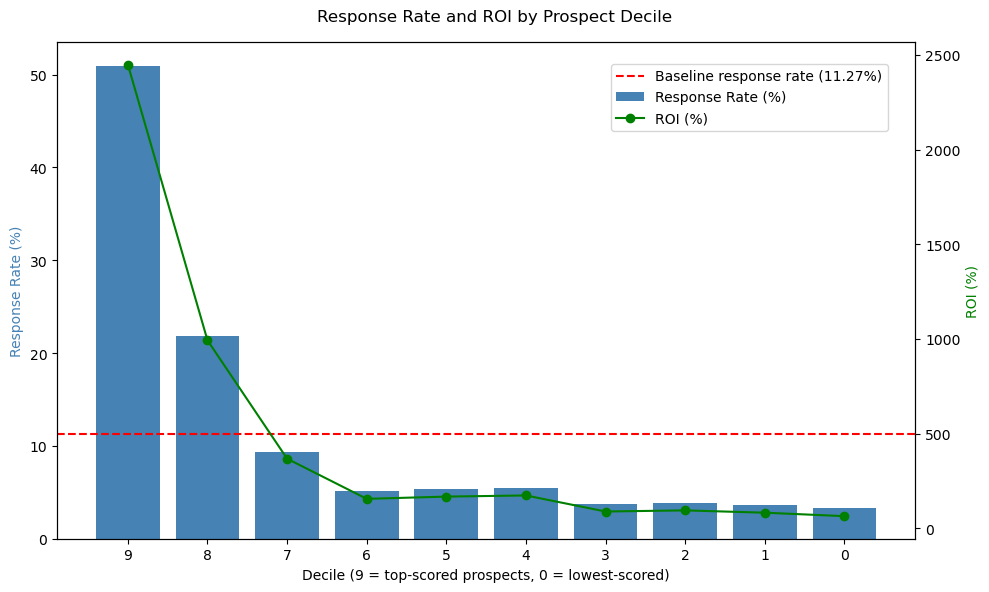

In [32]:
# Sort deciles from top (9) to bottom (0) for a left-to-right "best to worst" view
plot_data = decile_summary.sort_index(ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for response rate
ax1.bar(plot_data.index.astype(str), plot_data['response_rate'] * 100, color='steelblue', label='Response Rate (%)')
ax1.set_xlabel('Decile (9 = top-scored prospects, 0 = lowest-scored)')
ax1.set_ylabel('Response Rate (%)', color='steelblue')
ax1.axhline(y=11.27, color='red', linestyle='--', label='Baseline response rate (11.27%)')

# Second axis for ROI %
ax2 = ax1.twinx()
ax2.plot(plot_data.index.astype(str), plot_data['roi_pct'], color='green', marker='o', label='ROI (%)')
ax2.set_ylabel('ROI (%)', color='green')

fig.suptitle('Response Rate and ROI by Prospect Decile')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.savefig('decile_response_roi_chart.png', dpi=150)
plt.show()

In [33]:
# Export the decile/ROI summary — this is the main table for the dashboard
decile_summary.reset_index().to_csv('decile_roi_summary.csv', index=False)

# export row-level data with predictions, in case we want to slice further in Power BI
results.to_csv('model_predictions_full.csv', index=False)

### **Phase 6 :** Dashboard

### **Final Key Insight:**
- By targeting just the top 20% of prospects, we still reach 65% of all responders while mailing 80% fewer people. The top 10% alone return a 2,449% ROI. With a limited budget, this is where spend should go first.